# Cross-Guideline Experiment Analysis

This notebook visualizes the results of testing 6 datasets (without guidelines) against 4 available annotation guidelines to identify which annotation style was likely used for each dataset.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

In [2]:
# Load the most recent summary file
output_dir = Path("cross_guideline_outputs")
summary_files = sorted(output_dir.glob("cross_guideline_SUMMARY_*.json"))

if not summary_files:
    raise FileNotFoundError(
        "No summary file found. Run the experiment first:\n"
        "  uv run python gaic/cross_guideline_experiment.py"
    )

summary_file = summary_files[-1]  # Most recent
print(f"Loading: {summary_file}")

with open(summary_file) as f:
    summary = json.load(f)

print(f"Timestamp: {summary['timestamp']}")
print(f"Model: {summary['model']}")
print(f"Sample size per dataset: {summary['sample_size_per_dataset']}")

Loading: cross_guideline_outputs/cross_guideline_SUMMARY_20260131_165805.json
Timestamp: 2026-01-31T17:26:23.462645
Model: llama3.1:8b
Sample size per dataset: 10


In [3]:
# Extract data into DataFrames
datasets = summary["datasets_tested"]
guidelines = summary["guideline_sources"]
matrix = summary["matrix_4x6"]

# Create accuracy and F1 matrices
accuracy_data = {
    guideline: [matrix[guideline][ds]["accuracy"] for ds in datasets]
    for guideline in guidelines
}
f1_data = {
    guideline: [matrix[guideline][ds]["f1_score"] for ds in datasets]
    for guideline in guidelines
}

df_accuracy = pd.DataFrame(accuracy_data, index=datasets).T
df_f1 = pd.DataFrame(f1_data, index=datasets).T

print("Accuracy Matrix:")
display(df_accuracy.round(3))
print("\nF1 Score Matrix:")
display(df_f1.round(3))

Accuracy Matrix:


,ACQUA,AEC,AFS,FINARG,IAM,SCIARK
ABSTRCT,0.8,0.5,0.8,0.5,0.8,0.8
ARGUMINSCI,0.5,0.5,0.5,0.4,0.8,0.7
PE,0.6,0.5,0.8,0.5,0.8,0.7
USELEC,0.5,0.5,0.8,0.5,0.8,0.8



F1 Score Matrix:


,ACQUA,AEC,AFS,FINARG,IAM,SCIARK
ABSTRCT,0.800,0.667,0.833,0.444,0.833,0.800
ARGUMINSCI,0.545,0.667,0.667,0.500,0.833,0.727
PE,0.500,0.615,0.833,0.444,0.833,0.571
USELEC,0.545,0.615,0.833,0.444,0.833,0.800


## Plot 1: Heatmap of Accuracy Scores

Shows how well each guideline performs on each dataset. Higher values (darker colors) indicate better alignment between the guideline's annotation style and the dataset's labeling conventions.

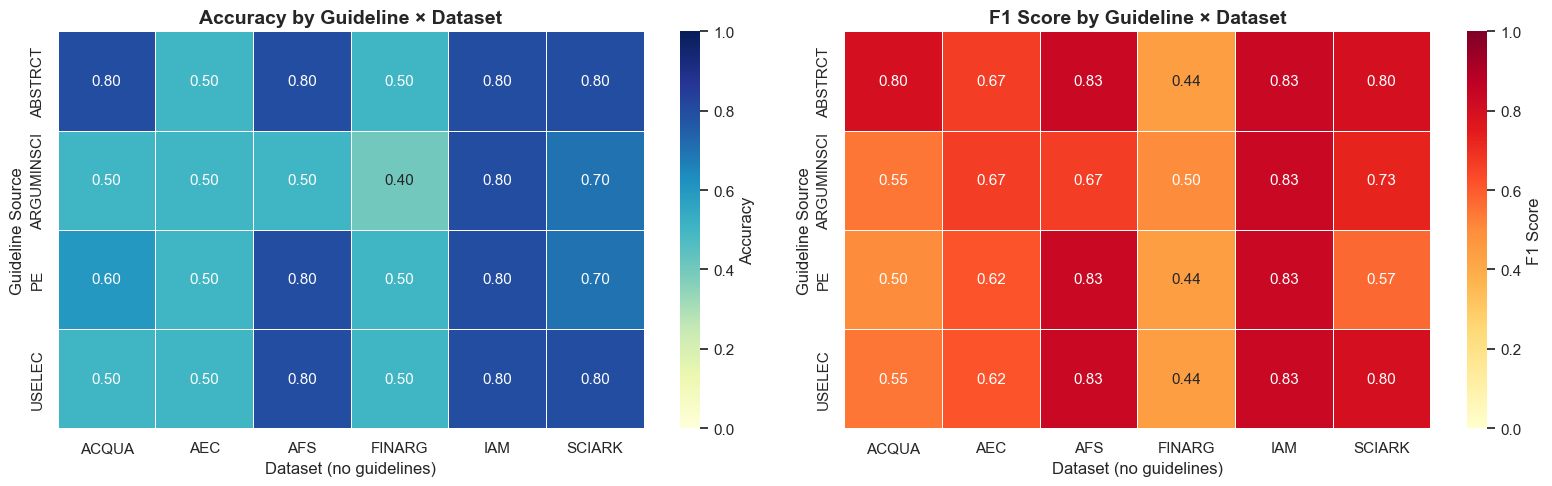

Saved: cross_guideline_outputs/heatmap_guideline_performance.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy heatmap
sns.heatmap(
    df_accuracy,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    ax=axes[0],
    cbar_kws={"label": "Accuracy"},
    linewidths=0.5,
)
axes[0].set_title("Accuracy by Guideline × Dataset", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Dataset (no guidelines)", fontsize=12)
axes[0].set_ylabel("Guideline Source", fontsize=12)

# F1 heatmap
sns.heatmap(
    df_f1,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    ax=axes[1],
    cbar_kws={"label": "F1 Score"},
    linewidths=0.5,
)
axes[1].set_title("F1 Score by Guideline × Dataset", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Dataset (no guidelines)", fontsize=12)
axes[1].set_ylabel("Guideline Source", fontsize=12)

plt.tight_layout()
plt.savefig("cross_guideline_outputs/heatmap_guideline_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cross_guideline_outputs/heatmap_guideline_performance.png")

## Plot 2: Best Guideline per Dataset

Bar chart showing the best-performing guideline for each dataset, with accuracy scores. This helps identify which annotation style most closely matches each dataset's labeling conventions.

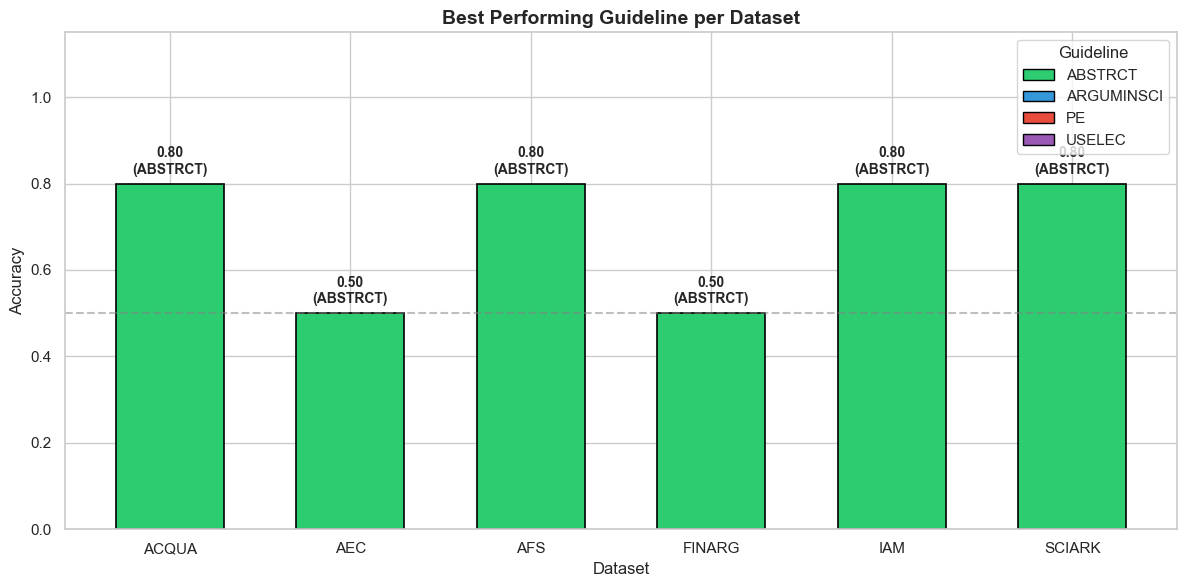

Saved: cross_guideline_outputs/best_guideline_per_dataset.png


In [5]:
# Extract best guideline info
best_info = summary["best_guideline_per_dataset"]

best_guidelines = [best_info[ds]["best_guideline"] for ds in datasets]
best_accuracies = [best_info[ds]["accuracy"] for ds in datasets]
best_f1s = [best_info[ds]["f1_score"] for ds in datasets]

# Color palette for guidelines
guideline_colors = {
    "ABSTRCT": "#2ecc71",
    "ARGUMINSCI": "#3498db",
    "PE": "#e74c3c",
    "USELEC": "#9b59b6",
}
bar_colors = [guideline_colors[g] for g in best_guidelines]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(datasets))
width = 0.6

bars = ax.bar(x, best_accuracies, width, color=bar_colors, edgecolor="black", linewidth=1.2)

# Add value labels on bars
for bar, acc, f1, guideline in zip(bars, best_accuracies, best_f1s, best_guidelines):
    height = bar.get_height()
    ax.annotate(
        f"{acc:.2f}\n({guideline})",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Best Performing Guideline per Dataset", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")

# Legend for guideline colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor="black", label=name) 
                   for name, color in guideline_colors.items()]
ax.legend(handles=legend_elements, loc="upper right", title="Guideline")

plt.tight_layout()
plt.savefig("cross_guideline_outputs/best_guideline_per_dataset.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cross_guideline_outputs/best_guideline_per_dataset.png")

## Summary Table

In [6]:
# Create summary table
summary_df = pd.DataFrame({
    "Dataset": datasets,
    "Best Guideline": best_guidelines,
    "Accuracy": best_accuracies,
    "F1 Score": best_f1s,
})

# Add runner-up info
runner_ups = []
for ds in datasets:
    all_results = best_info[ds]["all_results"]
    sorted_results = sorted(all_results.items(), key=lambda x: x[1]["accuracy"], reverse=True)
    if len(sorted_results) > 1:
        runner_up = sorted_results[1]
        runner_ups.append(f"{runner_up[0]} ({runner_up[1]['accuracy']:.2f})")
    else:
        runner_ups.append("-")

summary_df["Runner-up"] = runner_ups

print("\n" + "="*60)
print("CROSS-GUIDELINE EXPERIMENT RESULTS")
print("="*60)
display(summary_df.style.format({"Accuracy": "{:.3f}", "F1 Score": "{:.3f}"}))


CROSS-GUIDELINE EXPERIMENT RESULTS


,Dataset,Best Guideline,Accuracy,F1 Score,Runner-up
0,ACQUA,ABSTRCT,0.800,0.800,PE (0.60)
1,AEC,ABSTRCT,0.500,0.667,ARGUMINSCI (0.50)
2,AFS,ABSTRCT,0.800,0.833,PE (0.80)
3,FINARG,ABSTRCT,0.500,0.444,PE (0.50)
4,IAM,ABSTRCT,0.800,0.833,ARGUMINSCI (0.80)
5,SCIARK,ABSTRCT,0.800,0.800,USELEC (0.80)
